# MSDS 684 – Week 1 Lab
## Multi-Armed Bandits and MDP Foundations

**Topics:**
- Exploration vs. exploitation tradeoff
- Action-value methods (ε‑greedy, UCB)
- Markov Decision Processes (MDPs)
- Returns, value functions, Bellman equations
- Gymnasium API introduction

**Lab Objectives:**
1. Create a custom multi-armed bandit environment following Gymnasium API.
2. Implement ε‑greedy and UCB agents using NumPy.
3. Run experiments (2000 steps, 1000 runs) and compare parameter settings.
4. Explore standard Gymnasium environments (`FrozenLake-v1`, `Taxi-v3`).
5. Measure random policy performance and map MDP concepts to Gymnasium.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("Libraries imported successfully.")

Libraries imported successfully.


---
## Part 1: Custom Multi‑Armed Bandit Environment (Gymnasium API)

In [2]:
class BanditEnv(gym.Env):
    """
    A k-armed bandit environment following the Gymnasium API.
    Each arm gives a reward drawn from a Gaussian distribution with
    true mean q_star[a] and standard deviation 1.0.
    """
    metadata = {'render_modes': ['human']}

    def __init__(self, k=10, true_means=None, std=1.0):
        super().__init__()
        self.k = k
        self.std = std
        if true_means is None:
            self.true_means = np.random.randn(k)
        else:
            self.true_means = np.array(true_means)
        self.optimal_action = np.argmax(self.true_means)

        self.action_space = spaces.Discrete(k)
        # Observation is a placeholder (bandit has no state)
        self.observation_space = spaces.Discrete(1)

        self.state = 0  # dummy state

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.state = 0
        info = {}
        return self.state, info

    def step(self, action):
        assert self.action_space.contains(action), f"Invalid action {action}"
        mean = self.true_means[action]
        reward = np.random.normal(mean, self.std)
        terminated = False
        truncated = False
        info = {'optimal': action == self.optimal_action}
        return self.state, reward, terminated, truncated, info

    def render(self):
        pass

    def close(self):
        pass

### Agent Implementations

In [3]:
class EpsilonGreedyAgent:
    """ε‑greedy agent with sample‑average estimates."""
    def __init__(self, k, epsilon):
        self.k = k
        self.epsilon = epsilon
        self.reset()

    def reset(self):
        self.Q = np.zeros(self.k)
        self.N = np.zeros(self.k, dtype=int)

    def select_action(self):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.k)
        else:
            max_val = np.max(self.Q)
            best_actions = np.where(self.Q == max_val)[0]
            return np.random.choice(best_actions)

    def update(self, action, reward):
        self.N[action] += 1
        self.Q[action] += (reward - self.Q[action]) / self.N[action]


class UCBAgent:
    """Upper Confidence Bound (UCB1) agent."""
    def __init__(self, k, c=2.0):
        self.k = k
        self.c = c
        self.reset()

    def reset(self):
        self.Q = np.zeros(self.k)
        self.N = np.zeros(self.k, dtype=int)
        self.t = 0

    def select_action(self):
        self.t += 1
        if self.t <= self.k:
            return self.t - 1
        ucb_values = self.Q + self.c * np.sqrt(np.log(self.t) / self.N)
        max_val = np.max(ucb_values)
        best_actions = np.where(ucb_values == max_val)[0]
        return np.random.choice(best_actions)

    def update(self, action, reward):
        self.N[action] += 1
        self.Q[action] += (reward - self.Q[action]) / self.N[action]

### Experiment Runner

In [6]:
def run_experiment(agent_class, env_kwargs, agent_kwargs, n_steps=2000, n_runs=1000):
    """
    Run multiple independent runs of a bandit experiment.
    Returns average reward and average optimal action rate per step.
    """
    all_rewards = np.zeros((n_runs, n_steps))
    all_optimal = np.zeros((n_runs, n_steps))

    for run in range(n_runs):
        env = BanditEnv(**env_kwargs)
        agent = agent_class(**agent_kwargs)
        agent.reset()

        obs, info = env.reset(seed=run)
        for step in range(n_steps):
            action = agent.select_action()
            obs, reward, terminated, truncated, info = env.step(action)
            agent.update(action, reward)

            all_rewards[run, step] = reward
            all_optimal[run, step] = 1 if action == env.optimal_action else 0

    avg_rewards = all_rewards.mean(axis=0)
    avg_optimal = all_optimal.mean(axis=0)
    return avg_rewards, avg_optimal


def smooth(data, window=50):
    """Moving average smoothing for plotting."""
    if len(data) < window:
        return data
    return np.convolve(data, np.ones(window)/window, mode='same')


def plot_results(results_dict, title_prefix=""):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    linestyles = ['-', '--', '-.', ':']
    color_idx = 0

    for label, (rewards, optimal) in results_dict.items():
        color = colors[color_idx % len(colors)]
        ls = linestyles[(color_idx // len(colors)) % len(linestyles)]
        color_idx += 1

        steps = np.arange(1, len(rewards) + 1)
        axes[0].plot(steps, smooth(rewards), color=color, linestyle=ls, linewidth=2, label=label)
        axes[1].plot(steps, optimal * 100, color=color, linestyle=ls, linewidth=2, label=label)

    axes[0].set_xlabel('Steps', fontsize=12)
    axes[0].set_ylabel('Average Reward (smoothed)', fontsize=12)
    axes[0].set_title(f'{title_prefix}Average Reward over 1000 runs', fontsize=13)
    axes[0].legend(loc='best', fontsize=10)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_xlabel('Steps', fontsize=12)
    axes[1].set_ylabel('% Optimal Action', fontsize=12)
    axes[1].set_title(f'{title_prefix}Optimal Action Rate over 1000 runs', fontsize=13)
    axes[1].legend(loc='best', fontsize=10)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### Running Experiments

Running ε-greedy with ε=0.0...
Running ε-greedy with ε=0.01...
Running ε-greedy with ε=0.1...
Running ε-greedy with ε=0.2...


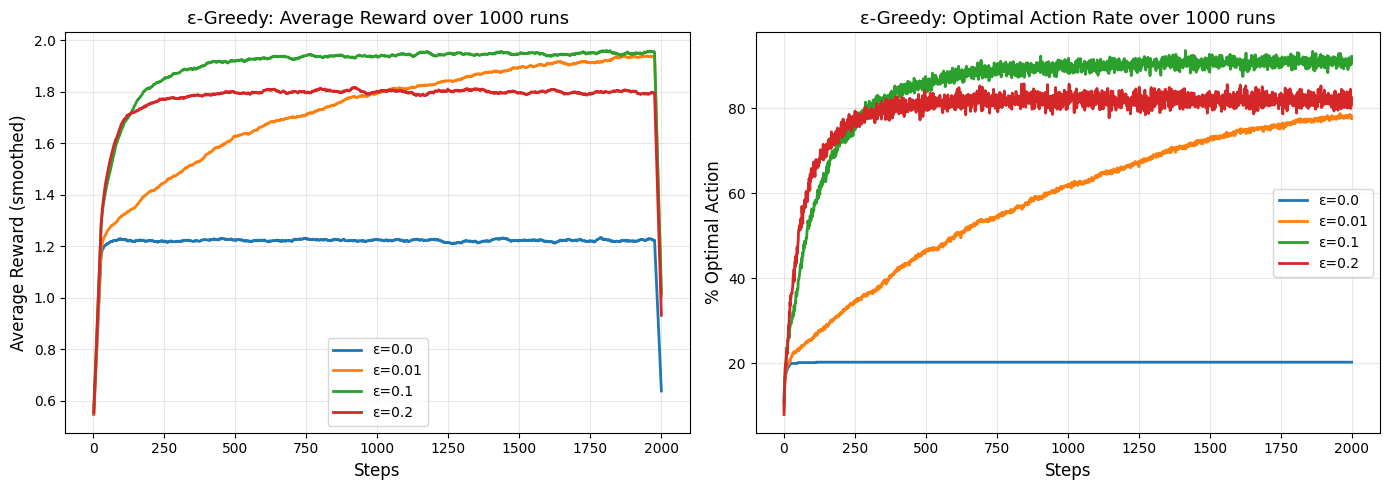

Running UCB with c=0.5...
Running UCB with c=1.0...
Running UCB with c=2.0...
Running UCB with c=4.0...


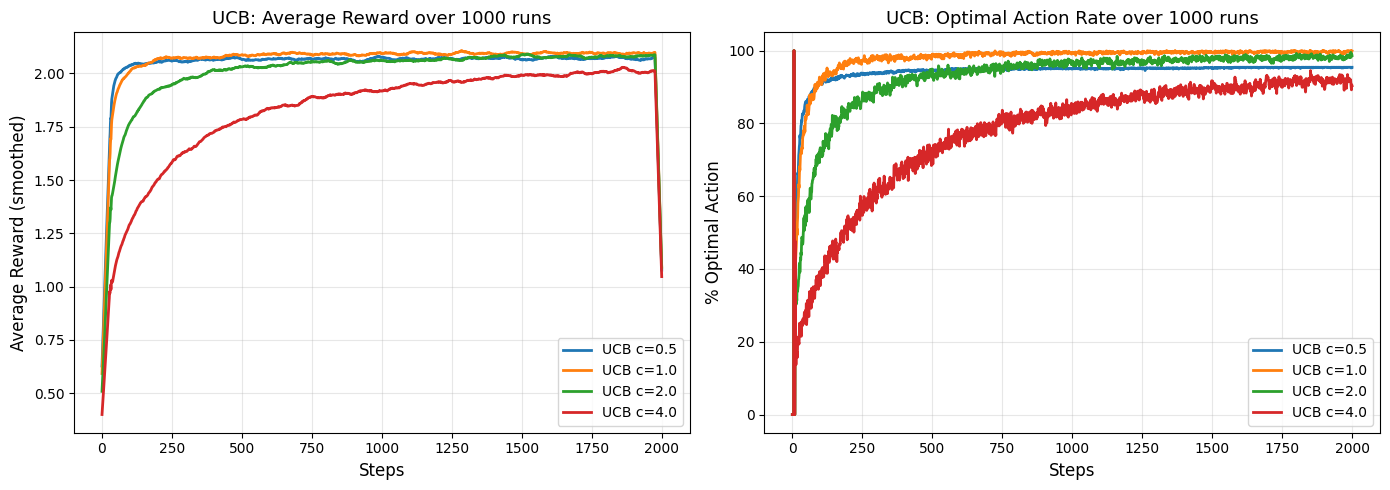

In [7]:
# Fixed true means for a 10-armed bandit
TRUE_MEANS = np.array([0.2, -0.5, 1.5, 0.8, -0.3, 0.9, 2.1, -0.1, 0.4, 1.1])
ENV_KWARGS = {'k': 10, 'true_means': TRUE_MEANS, 'std': 1.0}

# ε‑Greedy with different ε values
eps_results = {}
for eps in [0.0, 0.01, 0.1, 0.2]:
    print(f"Running ε-greedy with ε={eps}...")
    rewards, optimal = run_experiment(
        agent_class=EpsilonGreedyAgent,
        env_kwargs=ENV_KWARGS,
        agent_kwargs={'k': 10, 'epsilon': eps},
        n_steps=2000, n_runs=1000
    )
    eps_results[f'ε={eps}'] = (rewards, optimal)

plot_results(eps_results, title_prefix="ε-Greedy: ")

# UCB with different confidence levels c
ucb_results = {}
for c in [0.5, 1.0, 2.0, 4.0]:
    print(f"Running UCB with c={c}...")
    rewards, optimal = run_experiment(
        agent_class=UCBAgent,
        env_kwargs=ENV_KWARGS,
        agent_kwargs={'k': 10, 'c': c},
        n_steps=2000, n_runs=1000
    )
    ucb_results[f'UCB c={c}'] = (rewards, optimal)

plot_results(ucb_results, title_prefix="UCB: ")

**Observations:**
- ε=0 (pure greedy) often gets stuck on a suboptimal arm.
- ε=0.01 learns slowly but eventually finds the best arm.
- ε=0.1 and ε=0.2 converge faster but continue exploring, lowering asymptotic performance.
- For UCB, c=2 balances exploration well; c=4 over-explores; c=0.5 may converge prematurely.

---
## Part 2: Standard Gymnasium Environments

In [8]:
def inspect_environment(env_name):
    """Print observation and action space details."""
    env = gym.make(env_name)
    print(f"\n{'='*60}")
    print(f"Environment: {env_name}")
    print(f"{'='*60}")

    obs_space = env.observation_space
    print(f"Observation space: {obs_space}")
    if isinstance(obs_space, spaces.Discrete):
        print(f"  - Type: Discrete, Number of states: {obs_space.n}")
    elif isinstance(obs_space, spaces.Box):
        print(f"  - Type: Box, Shape: {obs_space.shape}")
        print(f"  - Low: {obs_space.low}, High: {obs_space.high}")

    act_space = env.action_space
    print(f"\nAction space: {act_space}")
    if isinstance(act_space, spaces.Discrete):
        print(f"  - Type: Discrete, Number of actions: {act_space.n}")
    elif isinstance(act_space, spaces.Box):
        print(f"  - Type: Box, Shape: {act_space.shape}")
        print(f"  - Low: {act_space.low}, High: {act_space.high}")

    env.close()

In [9]:
def evaluate_random_policy(env_name, n_episodes=100, max_steps=1000):
    """Run a random policy and report average return and length."""
    env = gym.make(env_name)
    total_rewards = []
    episode_lengths = []

    for ep in range(n_episodes):
        obs, info = env.reset(seed=ep)
        done = False
        ep_reward = 0
        steps = 0
        while not done and steps < max_steps:
            action = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            ep_reward += reward
            steps += 1
        total_rewards.append(ep_reward)
        episode_lengths.append(steps)

    env.close()
    avg_reward = np.mean(total_rewards)
    avg_length = np.mean(episode_lengths)
    print(f"\nRandom Policy on {env_name} ({n_episodes} episodes):")
    print(f"  Average return: {avg_reward:.2f}")
    print(f"  Average length: {avg_length:.2f}")
    if env_name == 'FrozenLake-v1':
        success_rate = np.mean([1 if r > 0 else 0 for r in total_rewards]) * 100
        print(f"  Success rate: {success_rate:.1f}%")
    return avg_reward, avg_length

In [10]:
inspect_environment('FrozenLake-v1')
inspect_environment('Taxi-v3')

evaluate_random_policy('FrozenLake-v1', n_episodes=1000)
evaluate_random_policy('Taxi-v3', n_episodes=100)


Environment: FrozenLake-v1
Observation space: Discrete(16)
  - Type: Discrete, Number of states: 16

Action space: Discrete(4)
  - Type: Discrete, Number of actions: 4

Environment: Taxi-v3
Observation space: Discrete(500)
  - Type: Discrete, Number of states: 500

Action space: Discrete(6)
  - Type: Discrete, Number of actions: 6

Random Policy on FrozenLake-v1 (1000 episodes):
  Average return: 0.02
  Average length: 7.52
  Success rate: 1.8%

Random Policy on Taxi-v3 (100 episodes):
  Average return: -769.79
  Average length: 195.26


(np.float64(-769.79), np.float64(195.26))

### MDP to Gymnasium Mapping

In [11]:
mdp_mapping = """
+-------------------+------------------------------------------------------+
| MDP Component     | Gymnasium Implementation                             |
+-------------------+------------------------------------------------------+
| State space S     | env.observation_space                                |
| Action space A    | env.action_space                                     |
| Transition P      | Hidden inside env.step(); not directly accessible.   |
| Reward function R | Returned by env.step() as the 'reward' value.        |
| Discount factor γ | Defined by the agent, not the environment.           |
| Policy π          | Implemented in agent.select_action().                |
| Episode           | Loop from env.reset() until terminated or truncated. |
+-------------------+------------------------------------------------------+
"""
print(mdp_mapping)


+-------------------+------------------------------------------------------+
| MDP Component     | Gymnasium Implementation                             |
+-------------------+------------------------------------------------------+
| State space S     | env.observation_space                                |
| Action space A    | env.action_space                                     |
| Transition P      | Hidden inside env.step(); not directly accessible.   |
| Reward function R | Returned by env.step() as the 'reward' value.        |
| Discount factor γ | Defined by the agent, not the environment.           |
| Policy π          | Implemented in agent.select_action().                |
| Episode           | Loop from env.reset() until terminated or truncated. |
+-------------------+------------------------------------------------------+



---
## Summary

In this lab we:
- Built a custom bandit environment compatible with Gymnasium.
- Implemented ε‑greedy and UCB agents using incremental updates.
- Ran extensive experiments to compare exploration strategies.
- Inspected standard Gymnasium environments and evaluated random policies.
- Connected theoretical MDP components to the Gymnasium API.

These skills form the foundation for all subsequent weeks of the course.